In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [82]:
# ============================================
# CELL 1: IMPORT LIBRARIES AND LOAD DATASET
# ============================================

import numpy as np
import pandas as pd
import re

import matplotlib.pyplot as plt
import seaborn as sns

# Dataset path
DATA_PATH = "/kaggle/input/datasets/mansithummar67/flipkart-product-review-dataset/flipkart_product.csv"

# Load dataset
df = pd.read_csv(
    DATA_PATH,
    encoding="latin1"
)

# Basic information
print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Shape: (189874, 5)

Columns:
['ProductName', 'Price', 'Rate', 'Review', 'Summary']

First 5 rows:


,ProductName,Price,Rate,Review,Summary
0,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"??3,999",5,Super!,Great cooler.. excellent air flow and for this...
1,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"??3,999",5,Awesome,Best budget 2 fit cooler. Nice cooling
2,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"??3,999",3,Fair,The quality is good but the power of air is de...
3,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"??3,999",1,Useless product,Very bad product it's a only a fan
4,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"??3,999",3,Fair,Ok ok product


In [83]:
# ============================================
# CELL 2: BASIC DATASET INSPECTION
# ============================================

print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nUnique Values:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Dataset Shape: (189874, 5)

Data Types:
ProductName    object
Price          object
Rate           object
Review         object
Summary        object
dtype: object

Missing Values:
ProductName     0
Price           1
Rate            1
Review          4
Summary        14
dtype: int64

Duplicate Rows:
24861

Unique Values:
ProductName: 812
Price: 561
Rate: 9
Review: 1264
Summary: 98343


In [85]:
# ============================================
# CELL 3: CLEAN RATING COLUMN
# ============================================

# Convert Rate into numeric
df["rating"] = pd.to_numeric(df["Rate"], errors="coerce")

print("Rating values before cleaning:")
print(df["rating"].value_counts(dropna=False).sort_index())

# Keep only valid ratings: 1, 2, 3, 4, 5
df = df[df["rating"].isin([1, 2, 3, 4, 5])].copy()

print("\nAfter cleaning:")
print("Shape:", df.shape)

print("\nValid Rating Distribution:")
print(df["rating"].value_counts().sort_index())

Rating values before cleaning:
rating
1     19607
2      6234
3     15681
4     39653
5    108694
Name: count, dtype: int64

After cleaning:
Shape: (189869, 6)

Valid Rating Distribution:
rating
1     19607
2      6234
3     15681
4     39653
5    108694
Name: count, dtype: int64


In [86]:
# ============================================
# CELL 4: CREATE SENTIMENT LABELS
# ============================================

def rating_to_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

# Create sentiment column
df["sentiment"] = df["rating"].apply(rating_to_sentiment)

# Sentiment distribution
print("Sentiment Distribution:")
print(df["sentiment"].value_counts())

print("\nSentiment Percentage:")
print(
    (df["sentiment"].value_counts(normalize=True) * 100).round(2)
)

Sentiment Distribution:
sentiment
Positive    148347
Negative     25841
Neutral      15681
Name: count, dtype: int64

Sentiment Percentage:
sentiment
Positive    78.13
Negative    13.61
Neutral      8.26
Name: proportion, dtype: float64


In [87]:
# ============================================
# CELL 5: TEXT CLEANING
# ============================================

def clean_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text)
    
    # Remove unwanted control characters
    text = re.sub(r"[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()


# Clean Review and Summary
df["Review_clean"] = df["Review"].apply(clean_text)
df["Summary_clean"] = df["Summary"].apply(clean_text)

# Combine both
df["full_text"] = (
    df["Review_clean"].fillna("") + " " +
    df["Summary_clean"].fillna("")
).str.strip()


# Check results
print("Text cleaning completed!")

print("\nSample cleaned text:")
display(df[["Review", "Summary", "full_text"]].head(10))

print("\nEmpty full_text:", df["full_text"].str.strip().eq("").sum())

Text cleaning completed!

Sample cleaned text:


,Review,Summary,full_text
0,Super!,Great cooler.. excellent air flow and for this...,Super! Great cooler.. excellent air flow and f...
1,Awesome,Best budget 2 fit cooler. Nice cooling,Awesome Best budget 2 fit cooler. Nice cooling
2,Fair,The quality is good but the power of air is de...,Fair The quality is good but the power of air ...
3,Useless product,Very bad product it's a only a fan,Useless product Very bad product it's a only a...
4,Fair,Ok ok product,Fair Ok ok product
5,Awesome,The cooler is really fantastic and provides go...,Awesome The cooler is really fantastic and pro...
6,Highly recommended,Very good product,Highly recommended Very good product
7,Nice,Very nice,Nice Very nice
8,Unsatisfactory,Very bad cooler,Unsatisfactory Very bad cooler
9,Worth the money,Very good,Worth the money Very good



Empty full_text: 0


In [88]:
# ============================================
# CELL 6: CLEAN PRODUCT NAME AND PRICE
# ============================================

def clean_product_name(text):
    if pd.isna(text):
        return ""
    
    text = str(text)
    
    # Remove corrupted characters
    text = text.replace("ÿ", "")
    text = text.replace("", "")
    
    # Remove repeated question marks
    text = re.sub(r"\?{2,}", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()


# Clean ProductName
df["ProductName_clean"] = df["ProductName"].apply(clean_product_name)


# Extract numeric price
df["Price_numeric"] = (
    df["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
)

df["Price_numeric"] = pd.to_numeric(
    df["Price_numeric"],
    errors="coerce"
)


# Display results
print("Product and Price cleaning completed!")

display(
    df[
        ["ProductName", "ProductName_clean", "Price", "Price_numeric"]
    ].head(10)
)

print("\nMissing numeric prices:", df["Price_numeric"].isna().sum())

Product and Price cleaning completed!


,ProductName,ProductName_clean,Price,Price_numeric
0,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"Candes 12 L Room/Personal Air Cooler (White, B...","??3,999",3999
1,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"Candes 12 L Room/Personal Air Cooler (White, B...","??3,999",3999
2,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"Candes 12 L Room/Personal Air Cooler (White, B...","??3,999",3999
3,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"Candes 12 L Room/Personal Air Cooler (White, B...","??3,999",3999
4,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"Candes 12 L Room/Personal Air Cooler (White, B...","??3,999",3999
5,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"Candes 12 L Room/Personal Air Cooler (White, B...","??3,999",3999
6,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"Candes 12 L Room/Personal Air Cooler (White, B...","??3,999",3999
7,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"Candes 12 L Room/Personal Air Cooler (White, B...","??3,999",3999
8,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"Candes 12 L Room/Personal Air Cooler (White, B...","??3,999",3999
9,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"Candes 12 L Room/Personal Air Cooler (White, B...","??3,999",3999



Missing numeric prices: 0


In [89]:
# ============================================
# CELL 7: REVIEW TEXT STATISTICS
# ============================================

# Number of words in each review
df["word_count"] = df["full_text"].apply(
    lambda x: len(str(x).split())
)

# Number of characters in each review
df["character_count"] = df["full_text"].apply(
    lambda x: len(str(x))
)

print("Review Text Statistics:")

print("\nWord Count:")
print(df["word_count"].describe().round(2))

print("\nCharacter Count:")
print(df["character_count"].describe().round(2))

print("\nShortest Review:")
print(df.loc[df["word_count"].idxmin(), "full_text"])

print("\nLongest Review:")
print(df.loc[df["word_count"].idxmax(), "full_text"])

Review Text Statistics:

Word Count:
count    189869.00
mean          9.47
std          12.89
min           1.00
25%           3.00
50%           5.00
75%           9.00
max         113.00
Name: word_count, dtype: float64

Character Count:
count    189869.00
mean         55.90
std          72.55
min           3.00
25%          21.00
50%          31.00
75%          57.00
max         677.00
Name: character_count, dtype: float64

Shortest Review:
Value-for-money

Longest Review:
Worried of recieving defective product but thanks to flipkart for replacing it with a brand new model of Bajaj FX11 FP I recieved this food processor within two days. Packing and delivery very good. But the processor is not at all starting. The time i set everything and turn the speed knob to start the motor the power light goes off. I tried for two hours in many ways following manual but no use. I called up bajaj customer care it is coming busy all time. With last hope called flipkart they understood problem and 

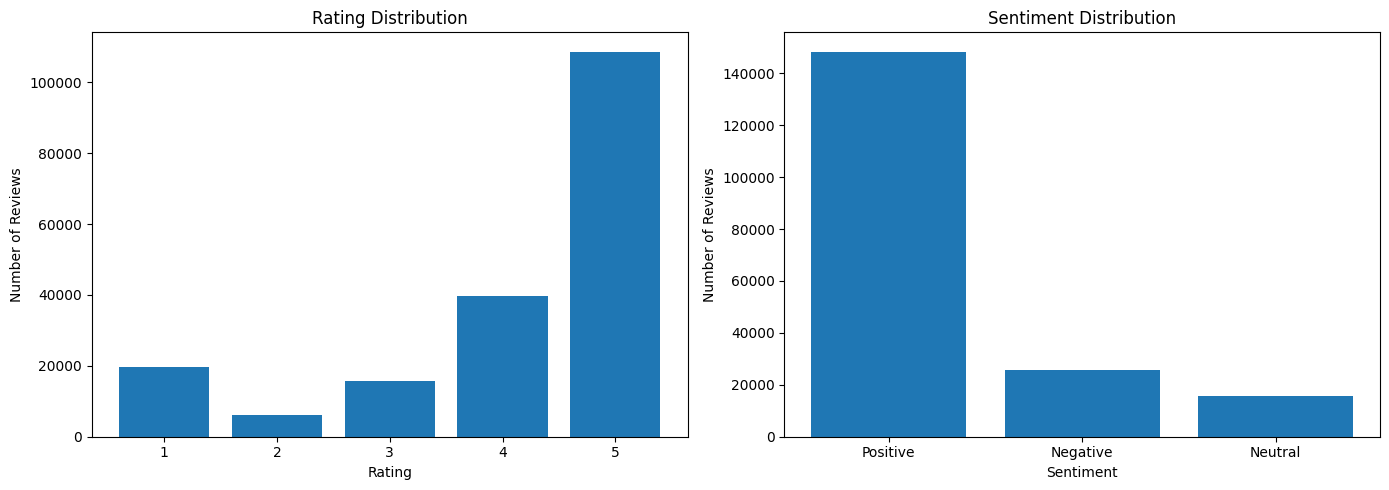

In [90]:
# ============================================
# CELL 8: RATING AND SENTIMENT VISUALIZATION
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating distribution
rating_counts = df["rating"].value_counts().sort_index()

axes[0].bar(
    rating_counts.index.astype(str),
    rating_counts.values
)

axes[0].set_title("Rating Distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Number of Reviews")


# Sentiment distribution
sentiment_counts = df["sentiment"].value_counts()

axes[1].bar(
    sentiment_counts.index,
    sentiment_counts.values
)

axes[1].set_title("Sentiment Distribution")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Number of Reviews")


plt.tight_layout()
plt.show()

In [91]:
# ============================================
# CELL 9: LOAD SPACY NLP MODEL
# ============================================

import spacy

# Load English NLP model
nlp = spacy.load("en_core_web_sm")

print("spaCy model loaded successfully!")

# Test sentence
test_text = "The camera quality is amazing but the battery backup is very poor."

doc = nlp(test_text)

print("\nToken and POS information:")
for token in doc:
    print(token.text, "----", token.pos_)

spaCy model loaded successfully!

Token and POS information:
The ---- DET
camera ---- NOUN
quality ---- NOUN
is ---- AUX
amazing ---- ADJ
but ---- CCONJ
the ---- DET
battery ---- NOUN
backup ---- NOUN
is ---- AUX
very ---- ADV
poor ---- ADJ
. ---- PUNCT


In [92]:
# ============================================
# CELL 10: CANDIDATE ASPECT EXTRACTION
# ============================================

def get_aspects(text):
    doc = nlp(str(text))
    
    aspects = []
    
    for token in doc:
        # Nouns and proper nouns can represent product aspects
        if token.pos_ in ["NOUN", "PROPN"]:
            word = token.text.lower().strip()
            
            # Ignore very short words
            if len(word) >= 3:
                aspects.append(word)
    
    return list(set(aspects))


# Test on our example
test_text = "The camera quality is amazing but the battery backup is very poor."

candidate_aspects = get_aspects(test_text)

print("Test Review:")
print(test_text)

print("\nCandidate Aspects:")
print(candidate_aspects)

Test Review:
The camera quality is amazing but the battery backup is very poor.

Candidate Aspects:
['backup', 'camera', 'battery', 'quality']


In [93]:
# ============================================
# CELL 11: ASPECT VOCABULARY
# ============================================

aspect_vocabulary = {
    # Camera
    "camera": "Camera",
    "photography": "Camera",
    "picture": "Camera",
    "photo": "Camera",

    # Battery
    "battery": "Battery",
    "backup": "Battery",
    "charging": "Battery",
    "charger": "Battery",

    # Display
    "display": "Display",
    "screen": "Display",
    "resolution": "Display",
    "touchscreen": "Display",

    # Sound
    "sound": "Sound",
    "speaker": "Sound",
    "speakers": "Sound",
    "audio": "Sound",
    "volume": "Sound",

    # Performance
    "performance": "Performance",
    "speed": "Performance",
    "processor": "Performance",
    "lag": "Performance",
    "hanging": "Performance",

    # Price
    "price": "Price",
    "cost": "Price",
    "value": "Price",
    "money": "Price",

    # Quality
    "quality": "Quality",

    # Build
    "build": "Build Quality",
    "material": "Build Quality",
    "plastic": "Build Quality",

    # Design
    "design": "Design",
    "colour": "Design",
    "color": "Design",
    "look": "Design",
    "looks": "Design",

    # Delivery
    "delivery": "Delivery",
    "shipping": "Delivery",

    # Packaging
    "packaging": "Packaging",
    "package": "Packaging",

    # Size and physical properties
    "size": "Size",
    "weight": "Weight",
    "capacity": "Capacity",

    # Cooler-related
    "cooler": "Cooler",
    "cooling": "Cooling",
    "air": "Airflow",
    "flow": "Airflow",
    "fan": "Fan",
    "power": "Power",
    "noise": "Noise",

    # Material
    "fabric": "Material",
    "cloth": "Material",

    # Service
    "service": "Service",
    "support": "Service",

    # Comfort and fit
    "comfort": "Comfort",
    "fit": "Fit",

    # Durability
    "durability": "Durability"
}

print("Total aspect keywords:", len(aspect_vocabulary))

print("\nAspect categories:")
print(sorted(set(aspect_vocabulary.values())))

Total aspect keywords: 56

Aspect categories:
['Airflow', 'Battery', 'Build Quality', 'Camera', 'Capacity', 'Comfort', 'Cooler', 'Cooling', 'Delivery', 'Design', 'Display', 'Durability', 'Fan', 'Fit', 'Material', 'Noise', 'Packaging', 'Performance', 'Power', 'Price', 'Quality', 'Service', 'Size', 'Sound', 'Weight']


In [94]:
# ============================================
# CELL 12: CLEAN ASPECT EXTRACTION
# ============================================

def get_clean_aspects(text):
    text = str(text).lower()
    
    found_aspects = []
    
    for keyword, category in aspect_vocabulary.items():
        pattern = r"\b" + re.escape(keyword) + r"\b"
        
        if re.search(pattern, text):
            found_aspects.append(category)
    
    return sorted(set(found_aspects))


# Test on sample reviews
test_reviews = [
    "Super! Great cooler.. excellent air flow and for this price.",
    "Awesome Best budget 2 fit cooler. Nice cooling",
    "Fair The quality is good but the power of air is decent",
    "Useless product Very bad product it's a only a fan",
    "The camera quality is amazing but the battery backup is very poor."
]

for review in test_reviews:
    print("\nReview:", review)
    print("Aspects:", get_clean_aspects(review))


Review: Super! Great cooler.. excellent air flow and for this price.
Aspects: ['Airflow', 'Cooler', 'Price']

Review: Awesome Best budget 2 fit cooler. Nice cooling
Aspects: ['Cooler', 'Cooling', 'Fit']

Review: Fair The quality is good but the power of air is decent
Aspects: ['Airflow', 'Power', 'Quality']

Review: Useless product Very bad product it's a only a fan
Aspects: ['Fan']

Review: The camera quality is amazing but the battery backup is very poor.
Aspects: ['Battery', 'Camera', 'Quality']


In [95]:
# ============================================
# CELL 13: EXTRACT ASPECTS FROM SAMPLE
# ============================================

# Take first 5,000 reviews for testing
sample_df = df.head(5000).copy()

# Extract normalized aspects
sample_df["aspects"] = sample_df["full_text"].apply(
    get_clean_aspects
)

# Show sample results
display(
    sample_df[
        ["full_text", "sentiment", "aspects"]
    ].head(20)
)

# Count reviews containing at least one aspect
reviews_with_aspects = (
    sample_df["aspects"].apply(len) > 0
).sum()

print("\nTotal sample reviews:", len(sample_df))
print("Reviews with at least one aspect:", reviews_with_aspects)
print(
    "Reviews without an aspect:",
    len(sample_df) - reviews_with_aspects
)

,full_text,sentiment,aspects
0,Super! Great cooler.. excellent air flow and f...,Positive,"[Airflow, Cooler, Price]"
1,Awesome Best budget 2 fit cooler. Nice cooling,Positive,"[Cooler, Cooling, Fit]"
2,Fair The quality is good but the power of air ...,Neutral,"[Airflow, Power, Quality]"
3,Useless product Very bad product it's a only a...,Negative,[Fan]
4,Fair Ok ok product,Neutral,[]
5,Awesome The cooler is really fantastic and pro...,Positive,"[Airflow, Cooler]"
6,Highly recommended Very good product,Positive,[]
7,Nice Very nice,Neutral,[]
8,Unsatisfactory Very bad cooler,Negative,[Cooler]
9,Worth the money Very good,Positive,[Price]



Total sample reviews: 5000
Reviews with at least one aspect: 2263
Reviews without an aspect: 2737


In [96]:
# ============================================
# CELL 14: ASPECT FREQUENCY ANALYSIS
# ============================================

from collections import Counter

# Combine all aspects from the sample
aspect_counter = Counter()

for aspects in sample_df["aspects"]:
    aspect_counter.update(aspects)

# Convert to DataFrame
aspect_frequency = pd.DataFrame(
    aspect_counter.items(),
    columns=["Aspect", "Frequency"]
)

# Sort by frequency
aspect_frequency = aspect_frequency.sort_values(
    "Frequency",
    ascending=False
).reset_index(drop=True)

print("Aspect Frequency:")
display(aspect_frequency)

print("\nTotal unique aspects found:", len(aspect_frequency))

Aspect Frequency:


,Aspect,Frequency
0,Quality,794
1,Price,745
2,Cooler,451
3,Cooling,341
4,Airflow,234
5,Design,187
6,Build Quality,173
7,Delivery,134
8,Size,132
9,Material,131



Total unique aspects found: 25


In [97]:
# ============================================
# CELL 15: SENTIMENT LEXICON
# ============================================

positive_words = {
    "amazing", "awesome", "excellent", "good", "great",
    "nice", "best", "fantastic", "wonderful", "brilliant",
    "super", "superb", "perfect", "beautiful", "love",
    "lovely", "satisfied", "satisfactory", "worth",
    "recommended", "recommend", "fabulous", "terrific",
    "happy", "smooth", "fast", "easy", "comfortable"
}

negative_words = {
    "bad", "poor", "worst", "useless", "waste",
    "wasteful", "disappointing", "disappointed", "terrible",
    "horrible", "awful", "unsatisfactory", "slow",
    "broken", "defective", "problem", "problems",
    "issue", "issues", "noisy", "expensive", "difficult",
    "uncomfortable", "rubbish", "damaged", "fake"
}

print("Positive words:", len(positive_words))
print("Negative words:", len(negative_words))

Positive words: 28
Negative words: 26


In [98]:
# ============================================
# CELL 16: ASPECT-LEVEL SENTIMENT FUNCTION
# ============================================

def get_aspect_sentiment(text, aspect, window=5):
    doc = nlp(str(text).lower())
    
    # Find the aspect keyword
    aspect_keywords = [
        keyword
        for keyword, category in aspect_vocabulary.items()
        if category == aspect
    ]
    
    aspect_positions = []
    
    # Find positions of aspect words
    for i, token in enumerate(doc):
        if token.text in aspect_keywords:
            aspect_positions.append(i)
    
    # If aspect is not found
    if not aspect_positions:
        return "Neutral", 0.0
    
    positive_count = 0
    negative_count = 0
    
    # Check words around the aspect
    for pos in aspect_positions:
        start = max(0, pos - window)
        end = min(len(doc), pos + window + 1)
        
        for token in doc[start:end]:
            word = token.text
            
            if word in positive_words:
                positive_count += 1
            
            elif word in negative_words:
                negative_count += 1
    
    # Determine sentiment
    if positive_count > negative_count:
        sentiment = "Positive"
    elif negative_count > positive_count:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"
    
    # Simple confidence score
    total = positive_count + negative_count
    
    if total == 0:
        confidence = 0.0
    else:
        confidence = abs(
            positive_count - negative_count
        ) / total
    
    return sentiment, round(confidence, 2)


# Test 1
text1 = "The camera quality is amazing but the battery backup is very poor."

print("Text:", text1)

print("Camera:",
      get_aspect_sentiment(text1, "Camera"))

print("Quality:",
      get_aspect_sentiment(text1, "Quality"))

print("Battery:",
      get_aspect_sentiment(text1, "Battery"))

Text: The camera quality is amazing but the battery backup is very poor.
Camera: ('Positive', 1.0)
Quality: ('Positive', 1.0)
Battery: ('Neutral', 0.0)


In [99]:
# ============================================
# CELL 17: IMPROVED ASPECT SENTIMENT FUNCTION
# ============================================

def get_aspect_sentiment(text, aspect, window=5):
    doc = nlp(str(text).lower())

    # Get all keywords belonging to this aspect
    aspect_keywords = {
        keyword
        for keyword, category in aspect_vocabulary.items()
        if category == aspect
    }

    # Find aspect positions
    aspect_positions = []

    for i, token in enumerate(doc):
        if token.text in aspect_keywords:
            aspect_positions.append(i)

    if not aspect_positions:
        return "Neutral", 0.0

    positive_count = 0
    negative_count = 0

    # Check nearby words
    for pos in aspect_positions:

        # Check both before and after the aspect
        start = max(0, pos - window)
        end = min(len(doc), pos + window + 1)

        for token in doc[start:end]:

            word = token.text.lower()

            if word in positive_words:
                positive_count += 1

            elif word in negative_words:
                negative_count += 1

    # Sentiment decision
    if positive_count > negative_count:
        sentiment = "Positive"
    elif negative_count > positive_count:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"

    # Confidence
    total = positive_count + negative_count

    if total == 0:
        confidence = 0.0
    else:
        confidence = abs(
            positive_count - negative_count
        ) / total

    return sentiment, round(confidence, 2)


# ============================================
# TEST
# ============================================

text1 = "The camera quality is amazing but the battery backup is very poor."

print("Text:", text1)

print("\nCamera:",
      get_aspect_sentiment(text1, "Camera"))

print("Quality:",
      get_aspect_sentiment(text1, "Quality"))

print("Battery:",
      get_aspect_sentiment(text1, "Battery"))

Text: The camera quality is amazing but the battery backup is very poor.

Camera: ('Positive', 1.0)
Quality: ('Positive', 1.0)
Battery: ('Neutral', 0.0)


In [100]:
# ============================================
# CELL 18: NEAREST SENTIMENT BASED ABSA
# ============================================

def get_aspect_sentiment(text, aspect, max_distance=6):
    doc = nlp(str(text).lower())

    # Keywords belonging to this aspect
    aspect_keywords = {
        keyword
        for keyword, category in aspect_vocabulary.items()
        if category == aspect
    }

    # Find positions of aspect keywords
    aspect_positions = []

    for i, token in enumerate(doc):
        if token.text in aspect_keywords:
            aspect_positions.append(i)

    if not aspect_positions:
        return "Neutral", 0.0

    # Find nearest sentiment word
    nearest_sentiment = None
    nearest_distance = float("inf")

    for aspect_pos in aspect_positions:

        for i, token in enumerate(doc):

            distance = abs(i - aspect_pos)

            if distance <= max_distance:

                word = token.text.lower()

                if word in positive_words or word in negative_words:

                    if distance < nearest_distance:
                        nearest_distance = distance
                        nearest_sentiment = word

    # No sentiment word found
    if nearest_sentiment is None:
        return "Neutral", 0.0

    # Determine sentiment
    if nearest_sentiment in positive_words:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    # Confidence based on distance
    confidence = round(
        1 - (nearest_distance / (max_distance + 1)),
        2
    )

    return sentiment, confidence


# ============================================
# TEST
# ============================================

text1 = "The camera quality is amazing but the battery backup is very poor."

print("Text:", text1)

print("\nCamera:",
      get_aspect_sentiment(text1, "Camera"))

print("Quality:",
      get_aspect_sentiment(text1, "Quality"))

print("Battery:",
      get_aspect_sentiment(text1, "Battery"))

Text: The camera quality is amazing but the battery backup is very poor.

Camera: ('Positive', 0.57)
Quality: ('Positive', 0.71)
Battery: ('Positive', 0.57)


In [101]:
# ============================================
# CELL 19: IMPROVED ASPECT SENTIMENT
# ============================================

def get_aspect_sentiment(text, aspect, max_distance=6):
    doc = nlp(str(text).lower())

    # Keywords belonging to this aspect
    aspect_keywords = {
        keyword
        for keyword, category in aspect_vocabulary.items()
        if category == aspect
    }

    # Find all positions of aspect keywords
    aspect_positions = [
        i for i, token in enumerate(doc)
        if token.text in aspect_keywords
    ]

    if not aspect_positions:
        return "Neutral", 0.0

    # Treat multiple keywords as one aspect phrase
    aspect_start = min(aspect_positions)
    aspect_end = max(aspect_positions)

    # ----------------------------------------
    # 1. First look AFTER the aspect
    # ----------------------------------------

    for distance in range(1, max_distance + 1):

        position = aspect_end + distance

        if position < len(doc):

            word = doc[position].text.lower()

            if word in positive_words:
                confidence = round(
                    1 - (distance / (max_distance + 1)), 2
                )
                return "Positive", confidence

            if word in negative_words:
                confidence = round(
                    1 - (distance / (max_distance + 1)), 2
                )
                return "Negative", confidence

    # ----------------------------------------
    # 2. Then look BEFORE the aspect
    # ----------------------------------------

    for distance in range(1, max_distance + 1):

        position = aspect_start - distance

        if position >= 0:

            word = doc[position].text.lower()

            if word in positive_words:
                confidence = round(
                    1 - (distance / (max_distance + 1)), 2
                )
                return "Positive", confidence

            if word in negative_words:
                confidence = round(
                    1 - (distance / (max_distance + 1)), 2
                )
                return "Negative", confidence

    # No sentiment word found
    return "Neutral", 0.0


# ============================================
# TEST
# ============================================

text1 = "The camera quality is amazing but the battery backup is very poor."

print("Text:", text1)

print("\nCamera:",
      get_aspect_sentiment(text1, "Camera"))

print("Quality:",
      get_aspect_sentiment(text1, "Quality"))

print("Battery:",
      get_aspect_sentiment(text1, "Battery"))

Text: The camera quality is amazing but the battery backup is very poor.

Camera: ('Positive', 0.57)
Quality: ('Positive', 0.71)
Battery: ('Negative', 0.57)


In [102]:
# ============================================
# CELL 20: TEST ABSA ON MULTIPLE REVIEWS
# ============================================

test_cases = [
    (
        "The camera quality is amazing but the battery backup is very poor.",
        ["Camera", "Quality", "Battery"]
    ),
    
    (
        "The cooler has excellent cooling but the noise is very high.",
        ["Cooler", "Cooling", "Noise"]
    ),
    
    (
        "The product quality is good and delivery was fast.",
        ["Quality", "Delivery"]
    ),
    
    (
        "The design is beautiful but the material is terrible.",
        ["Design", "Material"]
    ),
    
    (
        "The price is expensive and the service is disappointing.",
        ["Price", "Service"]
    )
]


for text, aspects in test_cases:
    
    print("\n" + "=" * 70)
    print("Review:", text)
    
    for aspect in aspects:
        sentiment, confidence = get_aspect_sentiment(
            text,
            aspect
        )
        
        print(
            f"{aspect:12} → "
            f"{sentiment:8} | "
            f"Confidence: {confidence * 100:.0f}%"
        )


Review: The camera quality is amazing but the battery backup is very poor.
Camera       → Positive | Confidence: 57%
Quality      → Positive | Confidence: 71%
Battery      → Negative | Confidence: 57%

Review: The cooler has excellent cooling but the noise is very high.
Cooler       → Positive | Confidence: 71%
Cooling      → Positive | Confidence: 86%
Noise        → Positive | Confidence: 43%

Review: The product quality is good and delivery was fast.
Quality      → Positive | Confidence: 71%
Delivery     → Positive | Confidence: 71%

Review: The design is beautiful but the material is terrible.
Design       → Positive | Confidence: 71%
Material     → Neutral  | Confidence: 0%

Review: The price is expensive and the service is disappointing.
Price        → Negative | Confidence: 71%
Service      → Negative | Confidence: 71%


In [103]:
# ============================================
# CELL 21: IMPROVE ASPECT SENTIMENT LOGIC
# ============================================

# Fix / extend aspect vocabulary
aspect_vocabulary.update({
    "material": "Material",
    "high": "Quality",
    "low": "Quality"
})

# Context-dependent sentiment words
aspect_negative_words = {
    "Noise": {"high", "loud", "noisy"},
    "Price": {"expensive", "costly", "high"},
    "Weight": {"heavy"},
    "Power": {"low", "weak"},
    "Performance": {"slow", "low", "weak"},
    "Cooling": {"low", "poor", "weak"},
    "Airflow": {"low", "poor", "weak"},
    "Battery": {"low", "poor", "weak"},
}

aspect_positive_words = {
    "Performance": {"high", "fast", "strong"},
    "Cooling": {"high", "strong", "excellent"},
    "Airflow": {"high", "strong", "excellent"},
    "Power": {"high", "strong"},
    "Battery": {"high", "strong"},
}

def get_aspect_sentiment(text, aspect, max_distance=6):
    doc = nlp(str(text).lower())

    aspect_keywords = {
        keyword
        for keyword, category in aspect_vocabulary.items()
        if category == aspect
    }

    aspect_positions = [
        i for i, token in enumerate(doc)
        if token.text in aspect_keywords
    ]

    if not aspect_positions:
        return "Neutral", 0.0

    aspect_start = min(aspect_positions)
    aspect_end = max(aspect_positions)

    # ----------------------------------------
    # 1. Check words AFTER the aspect
    # ----------------------------------------
    for distance in range(1, max_distance + 1):

        position = aspect_end + distance

        if position >= len(doc):
            continue

        word = doc[position].text.lower()

        # Context-dependent negative words
        if word in aspect_negative_words.get(aspect, set()):
            confidence = round(
                1 - (distance / (max_distance + 1)), 2
            )
            return "Negative", confidence

        # Context-dependent positive words
        if word in aspect_positive_words.get(aspect, set()):
            confidence = round(
                1 - (distance / (max_distance + 1)), 2
            )
            return "Positive", confidence

        # General sentiment words
        if word in positive_words:
            confidence = round(
                1 - (distance / (max_distance + 1)), 2
            )
            return "Positive", confidence

        if word in negative_words:
            confidence = round(
                1 - (distance / (max_distance + 1)), 2
            )
            return "Negative", confidence

    # ----------------------------------------
    # 2. Check words BEFORE the aspect
    # ----------------------------------------
    for distance in range(1, max_distance + 1):

        position = aspect_start - distance

        if position < 0:
            continue

        word = doc[position].text.lower()

        if word in aspect_negative_words.get(aspect, set()):
            confidence = round(
                1 - (distance / (max_distance + 1)), 2
            )
            return "Negative", confidence

        if word in aspect_positive_words.get(aspect, set()):
            confidence = round(
                1 - (distance / (max_distance + 1)), 2
            )
            return "Positive", confidence

        if word in positive_words:
            confidence = round(
                1 - (distance / (max_distance + 1)), 2
            )
            return "Positive", confidence

        if word in negative_words:
            confidence = round(
                1 - (distance / (max_distance + 1)), 2
            )
            return "Negative", confidence

    return "Neutral", 0.0


print("Improved ABSA logic loaded successfully!")

Improved ABSA logic loaded successfully!


In [104]:
# ============================================
# CELL 22: TEST IMPROVED ABSA
# ============================================

test_cases = [
    (
        "The camera quality is amazing but the battery backup is very poor.",
        ["Camera", "Quality", "Battery"]
    ),

    (
        "The cooler has excellent cooling but the noise is very high.",
        ["Cooler", "Cooling", "Noise"]
    ),

    (
        "The product quality is good and delivery was fast.",
        ["Quality", "Delivery"]
    ),

    (
        "The design is beautiful but the material is terrible.",
        ["Design", "Material"]
    ),

    (
        "The price is expensive and the service is disappointing.",
        ["Price", "Service"]
    )
]

for text, aspects in test_cases:
    print("\n" + "=" * 70)
    print("Review:", text)

    for aspect in aspects:
        sentiment, confidence = get_aspect_sentiment(
            text,
            aspect
        )

        print(
            f"{aspect:12} → "
            f"{sentiment:8} | "
            f"Confidence: {confidence * 100:.0f}%"
        )


Review: The camera quality is amazing but the battery backup is very poor.
Camera       → Positive | Confidence: 57%
Quality      → Positive | Confidence: 71%
Battery      → Negative | Confidence: 57%

Review: The cooler has excellent cooling but the noise is very high.
Cooler       → Positive | Confidence: 71%
Cooling      → Positive | Confidence: 14%
Noise        → Negative | Confidence: 57%

Review: The product quality is good and delivery was fast.
Quality      → Positive | Confidence: 71%
Delivery     → Positive | Confidence: 71%

Review: The design is beautiful but the material is terrible.
Design       → Positive | Confidence: 71%
Material     → Negative | Confidence: 71%

Review: The price is expensive and the service is disappointing.
Price        → Negative | Confidence: 71%
Service      → Negative | Confidence: 71%


In [105]:
# ============================================
# CELL 23: APPLY ABSA TO SAMPLE DATA
# ============================================

def analyze_review(text):
    aspects = get_clean_aspects(text)

    results = []

    for aspect in aspects:
        sentiment, confidence = get_aspect_sentiment(
            text,
            aspect
        )

        results.append({
            "aspect": aspect,
            "aspect_sentiment": sentiment,
            "confidence": confidence
        })

    return results


# Apply ABSA to 5,000 sample reviews
sample_df["absa_results"] = sample_df["full_text"].apply(analyze_review)

print("ABSA applied successfully!")

display(
    sample_df[
        ["full_text", "sentiment", "aspects", "absa_results"]
    ].head(20)
)

ABSA applied successfully!


,full_text,sentiment,aspects,absa_results
0,Super! Great cooler.. excellent air flow and f...,Positive,"[Airflow, Cooler, Price]","[{'aspect': 'Airflow', 'aspect_sentiment': 'Po..."
1,Awesome Best budget 2 fit cooler. Nice cooling,Positive,"[Cooler, Cooling, Fit]","[{'aspect': 'Cooler', 'aspect_sentiment': 'Pos..."
2,Fair The quality is good but the power of air ...,Neutral,"[Airflow, Power, Quality]","[{'aspect': 'Airflow', 'aspect_sentiment': 'Po..."
3,Useless product Very bad product it's a only a...,Negative,[Fan],"[{'aspect': 'Fan', 'aspect_sentiment': 'Neutra..."
4,Fair Ok ok product,Neutral,[],[]
5,Awesome The cooler is really fantastic and pro...,Positive,"[Airflow, Cooler]","[{'aspect': 'Airflow', 'aspect_sentiment': 'Po..."
6,Highly recommended Very good product,Positive,[],[]
7,Nice Very nice,Neutral,[],[]
8,Unsatisfactory Very bad cooler,Negative,[Cooler],"[{'aspect': 'Cooler', 'aspect_sentiment': 'Neg..."
9,Worth the money Very good,Positive,[Price],"[{'aspect': 'Price', 'aspect_sentiment': 'Posi..."


In [106]:
# ============================================
# CELL 24: CREATE ASPECT-SENTIMENT TABLE
# ============================================

aspect_rows = []

for _, row in sample_df.iterrows():

    for result in row["absa_results"]:

        aspect_rows.append({
            "ProductName": row["ProductName_clean"],
            "rating": row["rating"],
            "review_sentiment": row["sentiment"],
            "Review": row["full_text"],
            "Aspect": result["aspect"],
            "Aspect_Sentiment": result["aspect_sentiment"],
            "Confidence": result["confidence"]
        })


aspect_df = pd.DataFrame(aspect_rows)

print("Aspect-Sentiment table created!")
print("Shape:", aspect_df.shape)

print("\nColumns:")
print(aspect_df.columns.tolist())

print("\nFirst 20 rows:")
display(aspect_df.head(20))

Aspect-Sentiment table created!
Shape: (3949, 7)

Columns:
['ProductName', 'rating', 'review_sentiment', 'Review', 'Aspect', 'Aspect_Sentiment', 'Confidence']

First 20 rows:


,ProductName,rating,review_sentiment,Review,Aspect,Aspect_Sentiment,Confidence
0,"Candes 12 L Room/Personal Air Cooler (White, B...",5,Positive,Super! Great cooler.. excellent air flow and f...,Airflow,Positive,0.86
1,"Candes 12 L Room/Personal Air Cooler (White, B...",5,Positive,Super! Great cooler.. excellent air flow and f...,Cooler,Positive,0.71
2,"Candes 12 L Room/Personal Air Cooler (White, B...",5,Positive,Super! Great cooler.. excellent air flow and f...,Price,Positive,0.29
3,"Candes 12 L Room/Personal Air Cooler (White, B...",5,Positive,Awesome Best budget 2 fit cooler. Nice cooling,Cooler,Positive,0.71
4,"Candes 12 L Room/Personal Air Cooler (White, B...",5,Positive,Awesome Best budget 2 fit cooler. Nice cooling,Cooling,Positive,0.86
5,"Candes 12 L Room/Personal Air Cooler (White, B...",5,Positive,Awesome Best budget 2 fit cooler. Nice cooling,Fit,Positive,0.57
6,"Candes 12 L Room/Personal Air Cooler (White, B...",3,Neutral,Fair The quality is good but the power of air ...,Airflow,Positive,0.29
7,"Candes 12 L Room/Personal Air Cooler (White, B...",3,Neutral,Fair The quality is good but the power of air ...,Power,Positive,0.57
8,"Candes 12 L Room/Personal Air Cooler (White, B...",3,Neutral,Fair The quality is good but the power of air ...,Quality,Positive,0.71
9,"Candes 12 L Room/Personal Air Cooler (White, B...",1,Negative,Useless product Very bad product it's a only a...,Fan,Neutral,0.00


In [107]:
# ============================================
# CELL 25: ASPECT-WISE SENTIMENT DISTRIBUTION
# ============================================

aspect_sentiment_counts = pd.crosstab(
    aspect_df["Aspect"],
    aspect_df["Aspect_Sentiment"]
)

# Make sure all sentiment columns exist
for sentiment in ["Positive", "Neutral", "Negative"]:
    if sentiment not in aspect_sentiment_counts.columns:
        aspect_sentiment_counts[sentiment] = 0

aspect_sentiment_counts = aspect_sentiment_counts[
    ["Positive", "Neutral", "Negative"]
]

# Add total mentions
aspect_sentiment_counts["Total"] = aspect_sentiment_counts.sum(axis=1)

# Sort by total frequency
aspect_sentiment_counts = aspect_sentiment_counts.sort_values(
    "Total",
    ascending=False
)

print("Aspect-wise Sentiment Distribution:")
display(aspect_sentiment_counts)

Aspect-wise Sentiment Distribution:


Aspect_Sentiment,Positive,Neutral,Negative,Total
Aspect,,,,
Quality,531,127,221,879
Price,469,122,154,745
Cooler,296,119,36,451
Cooling,239,69,33,341
Airflow,131,80,23,234
Material,102,41,51,194
Design,114,59,14,187
Delivery,93,35,6,134
Size,59,51,22,132


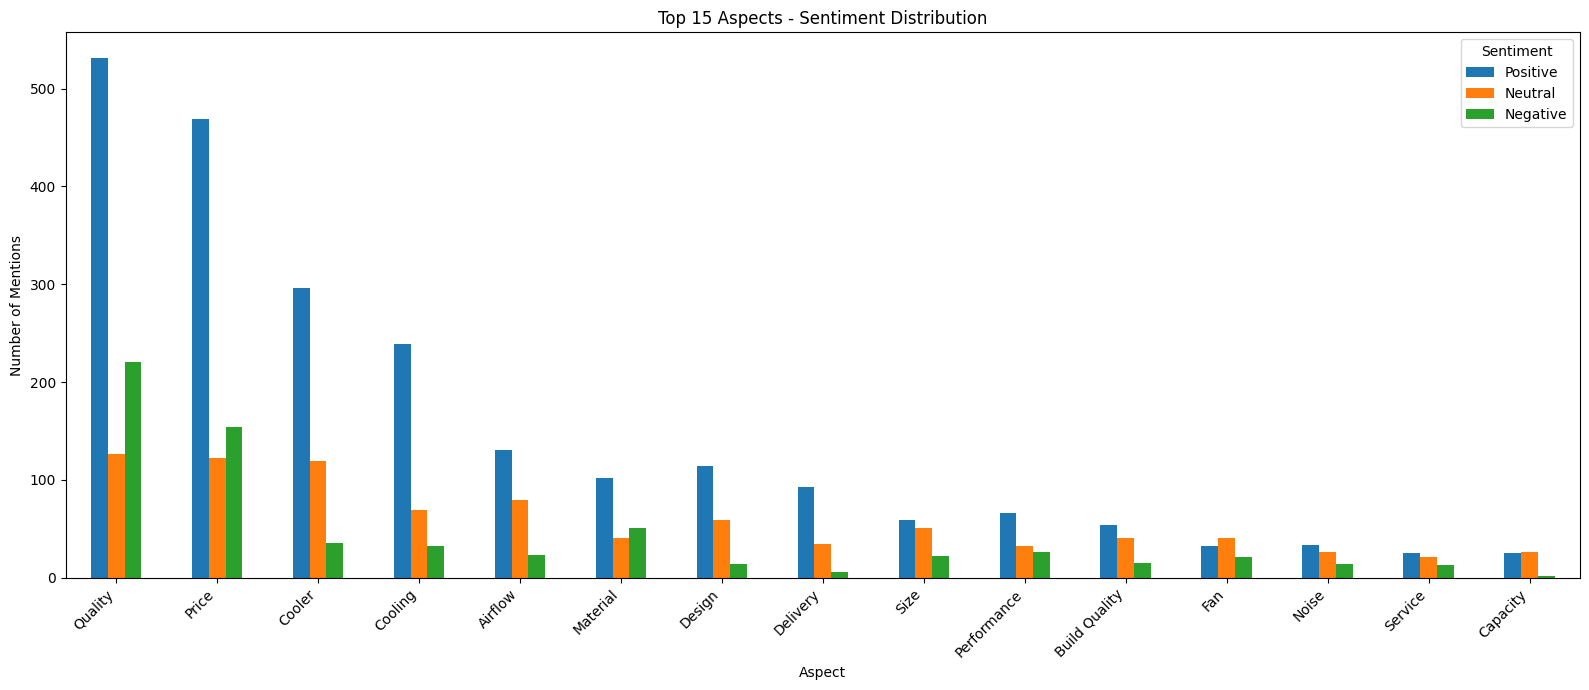

In [108]:
# ============================================
# CELL 26: ASPECT SENTIMENT VISUALIZATION
# ============================================

# Select top 15 aspects by total mentions
top_aspects = aspect_sentiment_counts.head(15)

plot_data = top_aspects[
    ["Positive", "Neutral", "Negative"]
]

ax = plot_data.plot(
    kind="bar",
    figsize=(16, 7)
)

plt.title("Top 15 Aspects - Sentiment Distribution")
plt.xlabel("Aspect")
plt.ylabel("Number of Mentions")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [109]:
# ============================================
# CELL 27: ASPECT-WISE SENTIMENT PERCENTAGE
# ============================================

percentage_data = aspect_sentiment_counts[
    ["Positive", "Neutral", "Negative"]
].div(
    aspect_sentiment_counts["Total"],
    axis=0
) * 100

percentage_data = percentage_data.round(2)

print("Aspect-wise Sentiment Percentage:")
display(percentage_data)


Aspect-wise Sentiment Percentage:


Aspect_Sentiment,Positive,Neutral,Negative
Aspect,,,
Quality,60.41,14.45,25.14
Price,62.95,16.38,20.67
Cooler,65.63,26.39,7.98
Cooling,70.09,20.23,9.68
Airflow,55.98,34.19,9.83
Material,52.58,21.13,26.29
Design,60.96,31.55,7.49
Delivery,69.40,26.12,4.48
Size,44.70,38.64,16.67


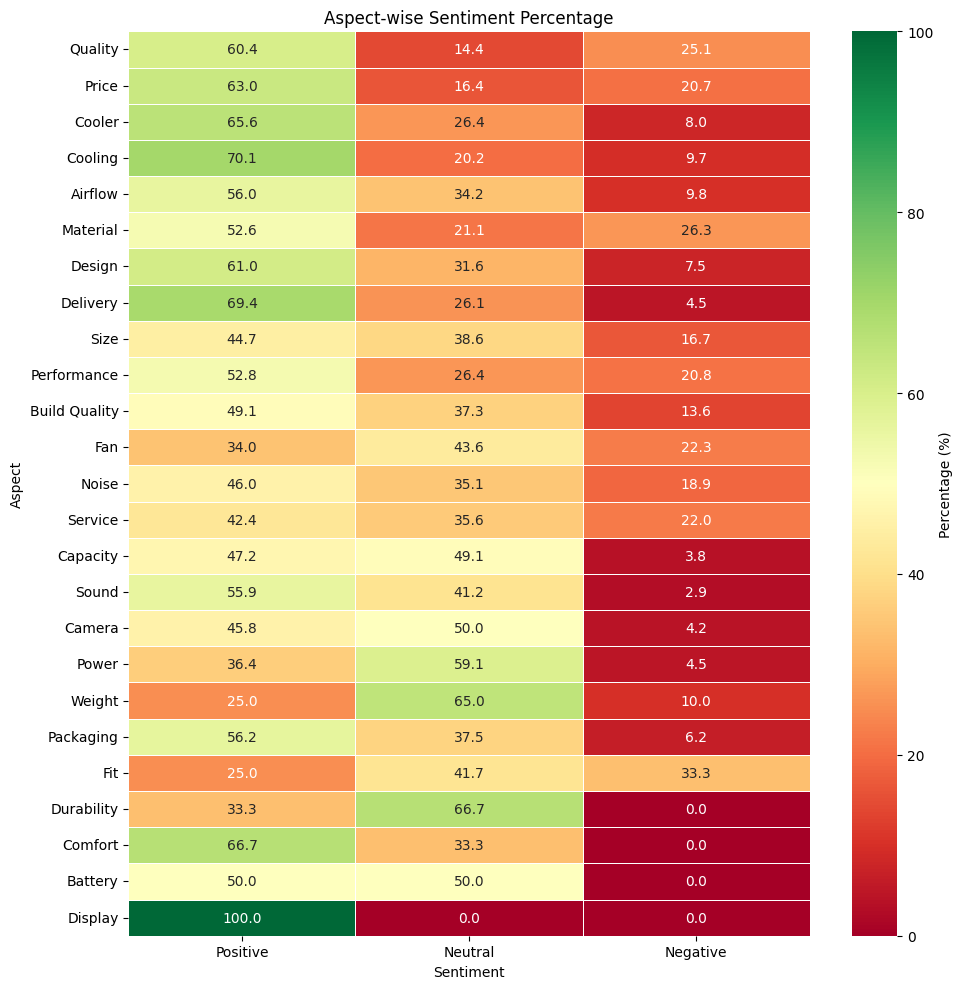

In [110]:
# ============================================
# CELL 28: ASPECT SENTIMENT HEATMAP
# ============================================

plt.figure(figsize=(10, 10))

sns.heatmap(
    percentage_data,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    linewidths=0.5,
    cbar_kws={"label": "Percentage (%)"}
)

plt.title("Aspect-wise Sentiment Percentage")
plt.xlabel("Sentiment")
plt.ylabel("Aspect")
plt.tight_layout()
plt.show()

In [111]:
# ============================================
# CELL 29: CONFIDENCE ANALYSIS
# ============================================

print("Confidence Statistics:")
print(
    aspect_df["Confidence"]
    .describe()
    .round(2)
)

print("\nConfidence Distribution:")

confidence_bins = pd.cut(
    aspect_df["Confidence"],
    bins=[-0.01, 0.25, 0.50, 0.75, 1.00],
    labels=[
        "Low (0-25%)",
        "Medium (26-50%)",
        "Good (51-75%)",
        "High (76-100%)"
    ]
)

confidence_distribution = confidence_bins.value_counts(
    sort=False
)

display(confidence_distribution.to_frame("Count"))

print("\nZero-confidence predictions:")
print(
    (aspect_df["Confidence"] == 0).sum()
)

Confidence Statistics:
count    3949.00
mean        0.47
std         0.33
min         0.00
25%         0.14
50%         0.57
75%         0.71
max         0.86
Name: Confidence, dtype: float64

Confidence Distribution:


,Count
Confidence,
Low (0-25%),1156
Medium (26-50%),609
Good (51-75%),1298
High (76-100%),886



Zero-confidence predictions:
958


In [112]:
# ============================================
# CELL 30: CONFIDENCE LEVEL CLASSIFICATION
# ============================================

def confidence_level(confidence):
    if confidence == 0:
        return "No Evidence"
    elif confidence <= 0.25:
        return "Low"
    elif confidence <= 0.50:
        return "Medium"
    elif confidence <= 0.75:
        return "Good"
    else:
        return "High"


aspect_df["Confidence_Level"] = (
    aspect_df["Confidence"]
    .apply(confidence_level)
)

print("Confidence levels added successfully!")

print("\nConfidence Level Distribution:")
display(
    aspect_df["Confidence_Level"]
    .value_counts()
)

print("\nPercentage Distribution:")
display(
    (
        aspect_df["Confidence_Level"]
        .value_counts(normalize=True) * 100
    ).round(2)
)

Confidence levels added successfully!

Confidence Level Distribution:


Confidence_Level
Good           1298
No Evidence     958
High            886
Medium          609
Low             198
Name: count, dtype: int64


Percentage Distribution:


Confidence_Level
Good           32.87
No Evidence    24.26
High           22.44
Medium         15.42
Low             5.01
Name: proportion, dtype: float64

In [113]:
# ============================================
# CELL 31: INSPECT LOW-CONFIDENCE PREDICTIONS
# ============================================

low_confidence_df = aspect_df[
    aspect_df["Confidence_Level"].isin(
        ["No Evidence", "Low"]
    )
].copy()

print("Total Low/No-Evidence predictions:",
      len(low_confidence_df))

print("\nSample Low/No-Evidence predictions:")

display(
    low_confidence_df[
        [
            "Review",
            "Aspect",
            "Aspect_Sentiment",
            "Confidence",
            "Confidence_Level"
        ]
    ].head(30)
)

Total Low/No-Evidence predictions: 1156

Sample Low/No-Evidence predictions:


,Review,Aspect,Aspect_Sentiment,Confidence,Confidence_Level
9,Useless product Very bad product it's a only a...,Fan,Neutral,0.00,No Evidence
25,Terrific purchase Very soundless product and l...,Price,Neutral,0.00,No Evidence
26,Terrific purchase Very soundless product and l...,Quality,Positive,0.14,Low
29,Good quality product cooler is big and wide . ...,Noise,Positive,0.14,Low
31,Good quality product cooler is big and wide . ...,Quality,Positive,0.14,Low
32,Good quality product cooler is big and wide . ...,Size,Neutral,0.00,No Evidence
34,Awesome It is one of the best air coolers at r...,Cooler,Neutral,0.00,No Evidence
35,Awesome It is one of the best air coolers at r...,Cooling,Neutral,0.00,No Evidence
37,Awesome It is one of the best air coolers at r...,Size,Neutral,0.00,No Evidence
40,Excellent Awesome Air coolerI was looking for ...,Cooler,Neutral,0.00,No Evidence


In [114]:
# ============================================
# CELL 32: IMPROVE ABSA WITH FALLBACK
# ============================================

def get_aspect_sentiment_v2(
    text,
    aspect,
    review_sentiment=None,
    max_distance=6
):
    # First: use our existing aspect-level logic
    sentiment, confidence = get_aspect_sentiment(
        text,
        aspect,
        max_distance
    )

    # If aspect-level evidence was found
    if confidence > 0:
        return sentiment, confidence, "Aspect Evidence"

    # ----------------------------------------
    # FALLBACK:
    # Use overall review sentiment with LOW
    # confidence because aspect evidence
    # was not explicitly found.
    # ----------------------------------------
    if review_sentiment in [
        "Positive",
        "Negative",
        "Neutral"
    ]:
        return review_sentiment, 0.14, "Review-Level Fallback"

    return "Neutral", 0.0, "No Evidence"


# Test the improved method
test_text = "Awesome It is one of the best air coolers at reasonable price."

print("Review:", test_text)

for aspect in ["Cooler", "Cooling", "Price"]:
    sentiment, confidence, evidence = get_aspect_sentiment_v2(
        test_text,
        aspect,
        review_sentiment="Positive"
    )

    print(
        f"{aspect:10} → "
        f"{sentiment:8} | "
        f"Confidence: {confidence:.2f} | "
        f"Evidence: {evidence}"
    )

Review: Awesome It is one of the best air coolers at reasonable price.
Cooler     → Positive | Confidence: 0.14 | Evidence: Review-Level Fallback
Cooling    → Positive | Confidence: 0.14 | Evidence: Review-Level Fallback
Price      → Positive | Confidence: 0.29 | Evidence: Aspect Evidence


In [115]:
# ============================================
# CELL 33: REGENERATE ABSA WITH FALLBACK
# ============================================

def analyze_review_v2(text, review_sentiment):
    aspects = get_clean_aspects(text)

    results = []

    for aspect in aspects:

        sentiment, confidence, evidence = get_aspect_sentiment_v2(
            text,
            aspect,
            review_sentiment=review_sentiment
        )

        results.append({
            "aspect": aspect,
            "aspect_sentiment": sentiment,
            "confidence": confidence,
            "evidence_type": evidence
        })

    return results


# Re-run ABSA on the 5,000-review sample
sample_df["absa_results_v2"] = sample_df.apply(
    lambda row: analyze_review_v2(
        row["full_text"],
        row["sentiment"]
    ),
    axis=1
)

print("Improved ABSA applied successfully!")

display(
    sample_df[
        [
            "full_text",
            "sentiment",
            "aspects",
            "absa_results_v2"
        ]
    ].head(20)
)

Improved ABSA applied successfully!


,full_text,sentiment,aspects,absa_results_v2
0,Super! Great cooler.. excellent air flow and f...,Positive,"[Airflow, Cooler, Price]","[{'aspect': 'Airflow', 'aspect_sentiment': 'Po..."
1,Awesome Best budget 2 fit cooler. Nice cooling,Positive,"[Cooler, Cooling, Fit]","[{'aspect': 'Cooler', 'aspect_sentiment': 'Pos..."
2,Fair The quality is good but the power of air ...,Neutral,"[Airflow, Power, Quality]","[{'aspect': 'Airflow', 'aspect_sentiment': 'Po..."
3,Useless product Very bad product it's a only a...,Negative,[Fan],"[{'aspect': 'Fan', 'aspect_sentiment': 'Negati..."
4,Fair Ok ok product,Neutral,[],[]
5,Awesome The cooler is really fantastic and pro...,Positive,"[Airflow, Cooler]","[{'aspect': 'Airflow', 'aspect_sentiment': 'Po..."
6,Highly recommended Very good product,Positive,[],[]
7,Nice Very nice,Neutral,[],[]
8,Unsatisfactory Very bad cooler,Negative,[Cooler],"[{'aspect': 'Cooler', 'aspect_sentiment': 'Neg..."
9,Worth the money Very good,Positive,[Price],"[{'aspect': 'Price', 'aspect_sentiment': 'Posi..."


In [117]:
# ============================================
# CELL 35: EXTRACT ASPECTS FROM FULL DATASET
# ============================================

print("Starting aspect extraction on full dataset...")

df["aspects"] = df["full_text"].apply(get_clean_aspects)

print("\nAspect extraction completed!")

total_reviews = len(df)
reviews_with_aspects = (df["aspects"].apply(len) > 0).sum()
reviews_without_aspects = total_reviews - reviews_with_aspects

print("Total reviews:", total_reviews)
print("Reviews with aspects:", reviews_with_aspects)
print("Reviews without aspects:", reviews_without_aspects)

print(
    "\nPercentage with aspects:",
    round((reviews_with_aspects / total_reviews) * 100, 2),
    "%"
)

print("\nSample results:")
display(
    df[
        ["full_text", "sentiment", "aspects"]
    ].head(20)
)

Starting aspect extraction on full dataset...

Aspect extraction completed!
Total reviews: 189869
Reviews with aspects: 65352
Reviews without aspects: 124517

Percentage with aspects: 34.42 %

Sample results:


,full_text,sentiment,aspects
0,Super! Great cooler.. excellent air flow and f...,Positive,"[Airflow, Cooler, Price]"
1,Awesome Best budget 2 fit cooler. Nice cooling,Positive,"[Cooler, Cooling, Fit]"
2,Fair The quality is good but the power of air ...,Neutral,"[Airflow, Power, Quality]"
3,Useless product Very bad product it's a only a...,Negative,[Fan]
4,Fair Ok ok product,Neutral,[]
5,Awesome The cooler is really fantastic and pro...,Positive,"[Airflow, Cooler]"
6,Highly recommended Very good product,Positive,[]
7,Nice Very nice,Neutral,[]
8,Unsatisfactory Very bad cooler,Negative,[Cooler]
9,Worth the money Very good,Positive,[Price]


In [116]:
# ============================================
# CELL 34: FINAL IMPROVED ASPECT TABLE
# ============================================

aspect_rows_v2 = []

for _, row in sample_df.iterrows():

    for result in row["absa_results_v2"]:

        aspect_rows_v2.append({
            "ProductName": row["ProductName_clean"],
            "rating": row["rating"],
            "review_sentiment": row["sentiment"],
            "Review": row["full_text"],
            "Aspect": result["aspect"],
            "Aspect_Sentiment": result["aspect_sentiment"],
            "Confidence": result["confidence"],
            "Evidence_Type": result["evidence_type"]
        })


aspect_df = pd.DataFrame(aspect_rows_v2)

print("Final improved Aspect-Sentiment table created!")

print("Shape:", aspect_df.shape)

print("\nColumns:")
print(aspect_df.columns.tolist())

print("\nEvidence Type Distribution:")
display(
    aspect_df["Evidence_Type"].value_counts()
)

print("\nFirst 10 rows:")
display(aspect_df.head(10))

Final improved Aspect-Sentiment table created!
Shape: (3949, 8)

Columns:
['ProductName', 'rating', 'review_sentiment', 'Review', 'Aspect', 'Aspect_Sentiment', 'Confidence', 'Evidence_Type']

Evidence Type Distribution:


Evidence_Type
Aspect Evidence          2991
Review-Level Fallback     958
Name: count, dtype: int64


First 10 rows:


,ProductName,rating,review_sentiment,Review,Aspect,Aspect_Sentiment,Confidence,Evidence_Type
0,"Candes 12 L Room/Personal Air Cooler (White, B...",5,Positive,Super! Great cooler.. excellent air flow and f...,Airflow,Positive,0.86,Aspect Evidence
1,"Candes 12 L Room/Personal Air Cooler (White, B...",5,Positive,Super! Great cooler.. excellent air flow and f...,Cooler,Positive,0.71,Aspect Evidence
2,"Candes 12 L Room/Personal Air Cooler (White, B...",5,Positive,Super! Great cooler.. excellent air flow and f...,Price,Positive,0.29,Aspect Evidence
3,"Candes 12 L Room/Personal Air Cooler (White, B...",5,Positive,Awesome Best budget 2 fit cooler. Nice cooling,Cooler,Positive,0.71,Aspect Evidence
4,"Candes 12 L Room/Personal Air Cooler (White, B...",5,Positive,Awesome Best budget 2 fit cooler. Nice cooling,Cooling,Positive,0.86,Aspect Evidence
5,"Candes 12 L Room/Personal Air Cooler (White, B...",5,Positive,Awesome Best budget 2 fit cooler. Nice cooling,Fit,Positive,0.57,Aspect Evidence
6,"Candes 12 L Room/Personal Air Cooler (White, B...",3,Neutral,Fair The quality is good but the power of air ...,Airflow,Positive,0.29,Aspect Evidence
7,"Candes 12 L Room/Personal Air Cooler (White, B...",3,Neutral,Fair The quality is good but the power of air ...,Power,Positive,0.57,Aspect Evidence
8,"Candes 12 L Room/Personal Air Cooler (White, B...",3,Neutral,Fair The quality is good but the power of air ...,Quality,Positive,0.71,Aspect Evidence
9,"Candes 12 L Room/Personal Air Cooler (White, B...",1,Negative,Useless product Very bad product it's a only a...,Fan,Negative,0.14,Review-Level Fallback


In [120]:
# ============================================
# CELL 35: ASPECT FREQUENCY ANALYSIS
# ============================================

from collections import Counter

aspect_counter_full = Counter()

for aspects in df["aspects"]:
    aspect_counter_full.update(aspects)

aspect_frequency_full = pd.DataFrame(
    aspect_counter_full.items(),
    columns=["Aspect", "Frequency"]
)

aspect_frequency_full = (
    aspect_frequency_full
    .sort_values("Frequency", ascending=False)
    .reset_index(drop=True)
)

print("Full Dataset Aspect Analysis")
print("Total unique aspects:", len(aspect_frequency_full))

print("\nTop 15 Aspects:")
display(aspect_frequency_full.head(15))

Full Dataset Aspect Analysis
Total unique aspects: 25

Top 15 Aspects:


,Aspect,Frequency
0,Quality,27698
1,Price,25897
2,Design,5589
3,Delivery,4027
4,Performance,3742
5,Sound,3401
6,Size,3086
7,Service,2621
8,Material,2573
9,Battery,2542


In [121]:
# ============================================
# CELL 36: ASPECT-WISE SENTIMENT ANALYSIS
# ============================================

aspect_sentiment_summary = (
    aspect_df
    .groupby(["Aspect", "Aspect_Sentiment"])
    .size()
    .unstack(fill_value=0)
)

# Make sure all sentiment columns exist
for col in ["Positive", "Neutral", "Negative"]:
    if col not in aspect_sentiment_summary.columns:
        aspect_sentiment_summary[col] = 0

# Calculate total mentions
aspect_sentiment_summary["Total"] = (
    aspect_sentiment_summary["Positive"]
    + aspect_sentiment_summary["Neutral"]
    + aspect_sentiment_summary["Negative"]
)

# Calculate percentages
aspect_sentiment_summary["Positive_%"] = (
    aspect_sentiment_summary["Positive"]
    / aspect_sentiment_summary["Total"] * 100
).round(2)

aspect_sentiment_summary["Neutral_%"] = (
    aspect_sentiment_summary["Neutral"]
    / aspect_sentiment_summary["Total"] * 100
).round(2)

aspect_sentiment_summary["Negative_%"] = (
    aspect_sentiment_summary["Negative"]
    / aspect_sentiment_summary["Total"] * 100
).round(2)

# Sort by total mentions
aspect_sentiment_summary = (
    aspect_sentiment_summary
    .sort_values("Total", ascending=False)
)

print("Aspect-wise Sentiment Analysis")

display(
    aspect_sentiment_summary[
        [
            "Positive",
            "Neutral",
            "Negative",
            "Total",
            "Positive_%",
            "Neutral_%",
            "Negative_%"
        ]
    ]
)

Aspect-wise Sentiment Analysis


Aspect_Sentiment,Positive,Neutral,Negative,Total,Positive_%,Neutral_%,Negative_%
Aspect,,,,,,,
Quality,593,28,258,879,67.46,3.19,29.35
Price,560,11,174,745,75.17,1.48,23.36
Cooler,376,17,58,451,83.37,3.77,12.86
Cooling,279,16,46,341,81.82,4.69,13.49
Airflow,179,11,44,234,76.50,4.70,18.80
Material,126,7,61,194,64.95,3.61,31.44
Design,143,13,31,187,76.47,6.95,16.58
Delivery,120,4,10,134,89.55,2.99,7.46
Size,82,11,39,132,62.12,8.33,29.55


In [122]:
# ============================================
# CELL 37: TOP POSITIVE & NEGATIVE ASPECTS
# ============================================

# Consider only aspects with at least 20 mentions
reliable_aspects = aspect_sentiment_summary[
    aspect_sentiment_summary["Total"] >= 20
].copy()

# --------------------------------------------
# Top Positive Aspects
# --------------------------------------------

top_positive_aspects = (
    reliable_aspects
    .sort_values(
        ["Positive_%", "Total"],
        ascending=[False, False]
    )
)

print("TOP POSITIVE ASPECTS")
display(
    top_positive_aspects[
        ["Positive", "Negative", "Total", "Positive_%", "Negative_%"]
    ].head(10)
)

# --------------------------------------------
# Top Negative Aspects
# --------------------------------------------

top_negative_aspects = (
    reliable_aspects
    .sort_values(
        ["Negative_%", "Total"],
        ascending=[False, False]
    )
)

print("\nTOP NEGATIVE ASPECTS")
display(
    top_negative_aspects[
        ["Positive", "Negative", "Total", "Positive_%", "Negative_%"]
    ].head(10)
)

TOP POSITIVE ASPECTS


Aspect_Sentiment,Positive,Negative,Total,Positive_%,Negative_%
Aspect,,,,,
Delivery,120,10,134,89.55,7.46
Cooler,376,58,451,83.37,12.86
Capacity,44,4,53,83.02,7.55
Cooling,279,46,341,81.82,13.49
Power,18,2,22,81.82,9.09
Airflow,179,44,234,76.50,18.80
Design,143,31,187,76.47,16.58
Price,560,174,745,75.17,23.36
Performance,91,28,125,72.80,22.40



TOP NEGATIVE ASPECTS


Aspect_Sentiment,Positive,Negative,Total,Positive_%,Negative_%
Aspect,,,,,
Service,32,24,59,54.24,40.68
Fan,54,34,94,57.45,36.17
Material,126,61,194,64.95,31.44
Weight,12,6,20,60.00,30.00
Size,82,39,132,62.12,29.55
Quality,593,258,879,67.46,29.35
Noise,49,19,74,66.22,25.68
Price,560,174,745,75.17,23.36
Build Quality,76,25,110,69.09,22.73


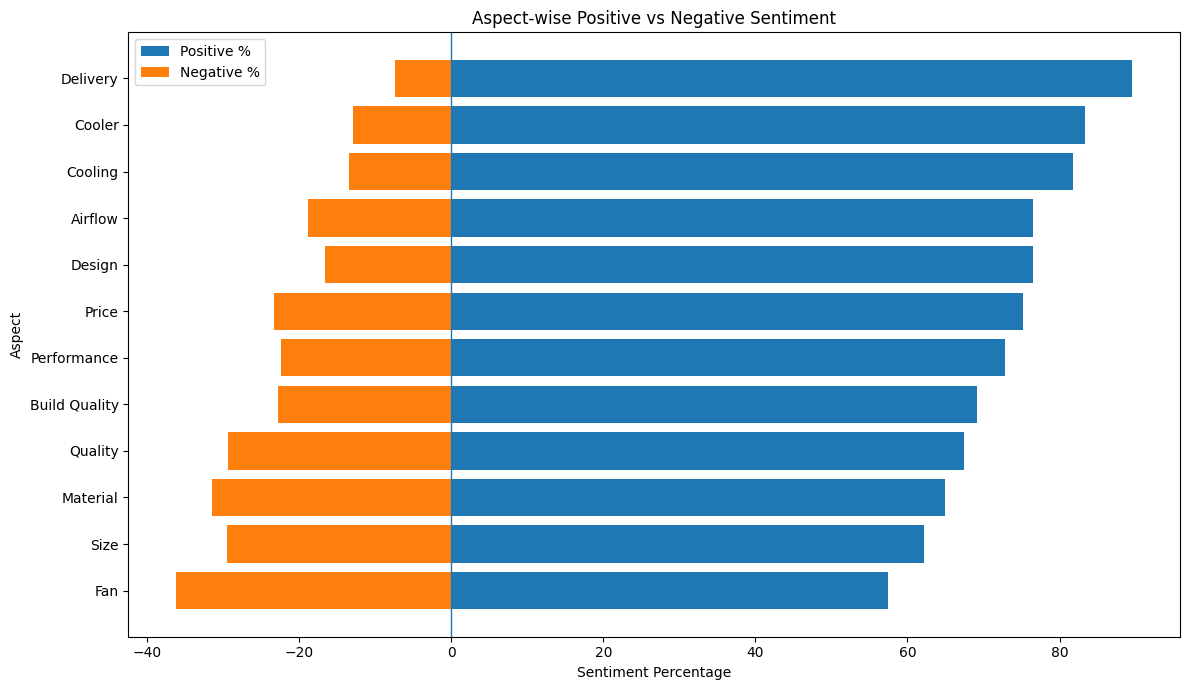

In [123]:
# ============================================
# CELL 38: POSITIVE vs NEGATIVE ASPECT CHART
# ============================================

plot_data = reliable_aspects.copy()

# Select aspects with highest combined importance
plot_data["Overall_Concern"] = (
    plot_data["Positive_%"] + plot_data["Negative_%"]
)

# Take top 12 by number of mentions
plot_data = (
    plot_data
    .sort_values("Total", ascending=False)
    .head(12)
    .sort_values("Positive_%")
)

plt.figure(figsize=(12, 7))

plt.barh(
    plot_data.index,
    plot_data["Positive_%"],
    label="Positive %"
)

plt.barh(
    plot_data.index,
    -plot_data["Negative_%"],
    label="Negative %"
)

plt.axvline(0, linewidth=1)

plt.xlabel("Sentiment Percentage")
plt.ylabel("Aspect")
plt.title("Aspect-wise Positive vs Negative Sentiment")

plt.legend()

plt.tight_layout()
plt.show()

In [124]:
# ============================================
# CELL 40: CONFIDENCE ANALYSIS
# ============================================

print("ABSA Confidence Analysis")

# Confidence categories
confidence_summary = (
    aspect_df["Evidence_Type"]
    .value_counts()
    .rename_axis("Evidence Type")
    .reset_index(name="Count")
)

confidence_summary["Percentage"] = (
    confidence_summary["Count"]
    / confidence_summary["Count"].sum()
    * 100
).round(2)

print("\nEvidence Type Distribution:")
display(confidence_summary)

# --------------------------------------------
# Confidence score statistics
# --------------------------------------------

print("\nConfidence Score Statistics:")

display(
    aspect_df["Confidence"].describe().round(2)
)

# --------------------------------------------
# Average confidence by evidence type
# --------------------------------------------

print("\nAverage Confidence by Evidence Type:")

display(
    aspect_df
    .groupby("Evidence_Type")["Confidence"]
    .agg(["count", "mean", "min", "max"])
    .round(2)
)

ABSA Confidence Analysis

Evidence Type Distribution:


,Evidence Type,Count,Percentage
0,Aspect Evidence,2991,75.74
1,Review-Level Fallback,958,24.26



Confidence Score Statistics:


count    3949.00
mean        0.51
std         0.28
min         0.14
25%         0.14
50%         0.57
75%         0.71
max         0.86
Name: Confidence, dtype: float64


Average Confidence by Evidence Type:


,count,mean,min,max
Evidence_Type,,,,
Aspect Evidence,2991,0.63,0.14,0.86
Review-Level Fallback,958,0.14,0.14,0.14


Confidence Level Distribution:


,Count
Confidence,
Low,1156
Medium,609
Good,1298
High,886



Confidence Level Percentage:


,Percentage
Confidence,
Low,29.27
Medium,15.42
Good,32.87
High,22.44


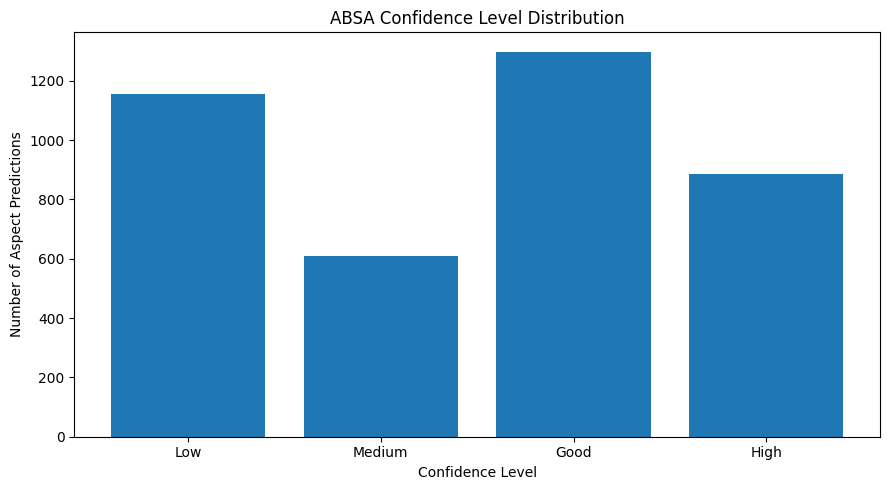

In [125]:
# ============================================
# CELL 41: CONFIDENCE DISTRIBUTION
# ============================================

confidence_bins = pd.cut(
    aspect_df["Confidence"],
    bins=[0, 0.25, 0.50, 0.75, 1.00],
    labels=["Low", "Medium", "Good", "High"],
    include_lowest=True
)

confidence_counts = confidence_bins.value_counts().sort_index()

print("Confidence Level Distribution:")
display(
    confidence_counts.to_frame("Count")
)

print("\nConfidence Level Percentage:")
display(
    (
        confidence_counts
        / confidence_counts.sum()
        * 100
    ).round(2).to_frame("Percentage")
)

# --------------------------------------------
# Visualization
# --------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    confidence_counts.index.astype(str),
    confidence_counts.values
)

plt.title("ABSA Confidence Level Distribution")
plt.xlabel("Confidence Level")
plt.ylabel("Number of Aspect Predictions")

plt.tight_layout()
plt.show()

In [126]:
# ============================================
# CELL 42: INTERACTIVE REVIEW ANALYZER
# ============================================

def review_analyzer(review):

    # Clean review
    review = clean_text(review)

    # Find aspects
    aspects = get_clean_aspects(review)

    if not aspects:
        return pd.DataFrame({
            "Message": [
                "No known product aspect detected in this review."
            ]
        })

    results = []

    for aspect in aspects:

        sentiment, confidence, evidence = get_aspect_sentiment_v2(
            review,
            aspect,
            review_sentiment=None
        )

        results.append({
            "Aspect": aspect,
            "Sentiment": sentiment,
            "Confidence": confidence,
            "Evidence": evidence
        })

    return pd.DataFrame(results)


# --------------------------------------------
# TEST REVIEW
# --------------------------------------------

test_review = (
    "The camera quality is amazing but the battery "
    "backup is very poor."
)

print("Review:")
print(test_review)

print("\nAnalysis:")

display(
    review_analyzer(test_review)
)

Review:
The camera quality is amazing but the battery backup is very poor.

Analysis:


,Aspect,Sentiment,Confidence,Evidence
0,Battery,Negative,0.57,Aspect Evidence
1,Camera,Positive,0.57,Aspect Evidence
2,Quality,Positive,0.71,Aspect Evidence


In [127]:
# ============================================
# CELL 43: INTERACTIVE REVIEW ANALYZER
# ============================================

print("=" * 60)
print("       PRODUCT REVIEW INTELLIGENCE SYSTEM")
print("       Aspect-Based Sentiment Analyzer")
print("=" * 60)

user_review = input("\nEnter a product review: ")

print("\nAnalyzing review...")
print("-" * 60)

result = review_analyzer(user_review)

display(result)

       PRODUCT REVIEW INTELLIGENCE SYSTEM
       Aspect-Based Sentiment Analyzer



Enter a product review:  The camera quality is excellent but battery backup is very poor.



Analyzing review...
------------------------------------------------------------


,Aspect,Sentiment,Confidence,Evidence
0,Battery,Negative,0.57,Aspect Evidence
1,Camera,Positive,0.57,Aspect Evidence
2,Quality,Positive,0.71,Aspect Evidence


In [128]:
# ============================================
# CELL 44: PRODUCT-WISE INTELLIGENCE
# ============================================

product_summary = (
    df.groupby("ProductName_clean")
    .agg(
        Review_Count=("rating", "count"),
        Average_Rating=("rating", "mean"),
        Positive_Reviews=("sentiment", lambda x: (x == "Positive").sum()),
        Neutral_Reviews=("sentiment", lambda x: (x == "Neutral").sum()),
        Negative_Reviews=("sentiment", lambda x: (x == "Negative").sum())
    )
    .reset_index()
)

# Calculate sentiment percentages
product_summary["Positive_%"] = (
    product_summary["Positive_Reviews"]
    / product_summary["Review_Count"] * 100
).round(2)

product_summary["Negative_%"] = (
    product_summary["Negative_Reviews"]
    / product_summary["Review_Count"] * 100
).round(2)

product_summary["Average_Rating"] = (
    product_summary["Average_Rating"].round(2)
)

# --------------------------------------------
# Remove products with very few reviews
# --------------------------------------------

reliable_products = product_summary[
    product_summary["Review_Count"] >= 50
].copy()

reliable_products = reliable_products.sort_values(
    "Review_Count",
    ascending=False
)

print("Product-wise Intelligence")
print("--------------------------------")

print("Total unique products:", len(product_summary))
print("Products with >= 50 reviews:", len(reliable_products))

print("\nTop 15 Products by Review Count:")

display(
    reliable_products[
        [
            "ProductName_clean",
            "Review_Count",
            "Average_Rating",
            "Positive_%",
            "Negative_%"
        ]
    ].head(15)
)

Product-wise Intelligence
--------------------------------
Total unique products: 811
Products with >= 50 reviews: 551

Top 15 Products by Review Count:


,ProductName_clean,Review_Count,Average_Rating,Positive_%,Negative_%
382,MILTON Thermosteel Flip Lid 500 ml FlaskÂ Â (P...,9278,4.45,88.35,5.36
775,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,8870,4.36,85.03,6.49
293,Home Sizzler 153 cm (5.02 ft) Polyester Room D...,4350,4.48,89.01,3.59
100,CMerchants Multi Organiser BLue-4 Book Shelf M...,2399,4.07,76.37,11.80
330,Kadio Analog 20 cm X 20 cm Wall ClockÂ Â (Beig...,2380,4.01,73.78,15.21
131,Cosito 144 TC Cotton Double Floral Flat Bedshe...,2322,4.12,77.35,11.54
464,Mi 5A 80 cm (32 inch) HD Ready LED Smart Andro...,2205,4.15,80.95,11.97
462,"Mi 3i 10000 mAh Power Bank (Fast Charging, 18W...",2006,4.26,83.40,10.82
638,Singer FM 1409 Electric Sewing MachineÂ Â ( Bu...,2003,4.35,86.32,7.04
415,Men Cargos,2000,3.64,62.95,25.40


In [129]:
# ============================================
# CELL 45: BEST & WORST PRODUCTS
# ============================================

# --------------------------------------------
# 1. Highest Rated Products
# --------------------------------------------

best_rated_products = (
    reliable_products
    .sort_values(
        ["Average_Rating", "Review_Count"],
        ascending=[False, False]
    )
)

print("TOP 10 HIGHEST-RATED PRODUCTS")
display(
    best_rated_products[
        [
            "ProductName_clean",
            "Review_Count",
            "Average_Rating",
            "Positive_%",
            "Negative_%"
        ]
    ].head(10)
)

# --------------------------------------------
# 2. Highest Negative Sentiment
# --------------------------------------------

most_negative_products = (
    reliable_products
    .sort_values(
        ["Negative_%", "Review_Count"],
        ascending=[False, False]
    )
)

print("\nTOP 10 PRODUCTS WITH HIGHEST NEGATIVE SENTIMENT")
display(
    most_negative_products[
        [
            "ProductName_clean",
            "Review_Count",
            "Average_Rating",
            "Positive_%",
            "Negative_%"
        ]
    ].head(10)
)

# --------------------------------------------
# 3. Lowest Rated Products
# --------------------------------------------

lowest_rated_products = (
    reliable_products
    .sort_values(
        ["Average_Rating", "Review_Count"],
        ascending=[True, False]
    )
)

print("\nTOP 10 LOWEST-RATED PRODUCTS")
display(
    lowest_rated_products[
        [
            "ProductName_clean",
            "Review_Count",
            "Average_Rating",
            "Positive_%",
            "Negative_%"
        ]
    ].head(10)
)

TOP 10 HIGHEST-RATED PRODUCTS


,ProductName_clean,Review_Count,Average_Rating,Positive_%,Negative_%
791,mCaffeine Coffee Moment Festive Skincare Gift ...,172,4.82,96.51,0.58
454,"Men Solid Single Breasted Formal, Wedding Blaz...",96,4.81,100.00,0.00
18,APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/M...,752,4.78,96.01,2.53
710,US DZIRE â¢ 512 Ganeshji craft Ceiling light ...,100,4.75,96.00,1.00
154,DRAMIQ Beautiful Kapoor Dani/Aroma Diffuser Cu...,88,4.75,93.18,4.55
61,BAJAJ Waterproof 1500 W Shock Proof Immersion ...,89,4.69,94.38,3.37
20,APPLE iPad (9th Gen) 64 GB ROM 10.2 inch with ...,1044,4.68,93.77,3.54
119,Chhariya Crafts Metal Krishna with Cow Standin...,100,4.68,97.00,1.00
19,APPLE iPad (9th Gen) 64 GB ROM 10.2 inch with ...,249,4.67,92.37,4.82
251,HAIR & CARE Triple Blend Damage Repair Non-Sti...,1999,4.65,93.20,1.90



TOP 10 PRODUCTS WITH HIGHEST NEGATIVE SENTIMENT


,ProductName_clean,Review_Count,Average_Rating,Positive_%,Negative_%
128,"Cloud Farm Dragon TreeÂ Â (Hybrid, Pack of 3)",100,2.20,25.00,68.00
12,AGRO ALIVE Red Sandalwood PlantÂ Â (Pack of 1),55,2.27,30.91,67.27
550,PrintStar 12A / Q2612A Compatible Toner Cartri...,100,2.29,33.00,64.00
796,realme 4k Smart Google TV Stick (Black) (Black),100,2.25,28.00,64.00
408,Medaline 250 Watt Ultra Thin Slim Ip66 LED Flo...,51,2.49,33.33,60.78
42,Aquagrand SkyLand 18 Ltr RO + UV + UF + TDS Wa...,200,2.71,42.50,54.50
545,Prestige PRWO 1.8-2 Electric Rice Cooker with ...,100,2.77,43.00,54.00
724,VERMI COMPOST 10 Kg of Pure Natural ORGANIC Co...,290,2.66,36.55,52.76
542,Prerana Microfibre Solid Cushion Pack of 5Â Â ...,190,2.66,35.79,52.63
640,Soaring Kids Study & Play Wooden Adjustable Fo...,82,2.82,40.24,52.44



TOP 10 LOWEST-RATED PRODUCTS


,ProductName_clean,Review_Count,Average_Rating,Positive_%,Negative_%
128,"Cloud Farm Dragon TreeÂ Â (Hybrid, Pack of 3)",100,2.20,25.00,68.00
796,realme 4k Smart Google TV Stick (Black) (Black),100,2.25,28.00,64.00
12,AGRO ALIVE Red Sandalwood PlantÂ Â (Pack of 1),55,2.27,30.91,67.27
550,PrintStar 12A / Q2612A Compatible Toner Cartri...,100,2.29,33.00,64.00
408,Medaline 250 Watt Ultra Thin Slim Ip66 LED Flo...,51,2.49,33.33,60.78
515,POOJA Maroon PP (Polypropylene) Area RugÂ Â (5...,93,2.65,35.48,51.61
724,VERMI COMPOST 10 Kg of Pure Natural ORGANIC Co...,290,2.66,36.55,52.76
579,"Riyahandlooms Cotton Floor MatÂ Â (Blue, Large...",200,2.66,32.50,49.00
542,Prerana Microfibre Solid Cushion Pack of 5Â Â ...,190,2.66,35.79,52.63
42,Aquagrand SkyLand 18 Ltr RO + UV + UF + TDS Wa...,200,2.71,42.50,54.50


In [130]:
# ============================================
# CELL 46: PROJECT KPI SUMMARY
# ============================================

total_reviews = len(df)

total_products = df["ProductName_clean"].nunique()

average_rating = df["rating"].mean()

positive_reviews = (df["sentiment"] == "Positive").sum()
neutral_reviews = (df["sentiment"] == "Neutral").sum()
negative_reviews = (df["sentiment"] == "Negative").sum()

reviews_with_aspects = (
    df["aspects"].apply(len) > 0
).sum()

total_aspect_mentions = (
    aspect_frequency_full["Frequency"].sum()
)

direct_evidence = (
    aspect_df["Evidence_Type"] == "Aspect Evidence"
).sum()

fallback_evidence = (
    aspect_df["Evidence_Type"] == "Review-Level Fallback"
).sum()

print("=" * 65)
print("       PRODUCT REVIEW INTELLIGENCE SYSTEM")
print("              PROJECT KPI SUMMARY")
print("=" * 65)

print(f"\nTotal Reviews              : {total_reviews:,}")
print(f"Total Products             : {total_products:,}")
print(f"Average Rating             : {average_rating:.2f} / 5")

print("\n--- REVIEW SENTIMENT ---")

print(
    f"Positive Reviews           : "
    f"{positive_reviews:,} "
    f"({positive_reviews / total_reviews * 100:.2f}%)"
)

print(
    f"Neutral Reviews            : "
    f"{neutral_reviews:,} "
    f"({neutral_reviews / total_reviews * 100:.2f}%)"
)

print(
    f"Negative Reviews           : "
    f"{negative_reviews:,} "
    f"({negative_reviews / total_reviews * 100:.2f}%)"
)

print("\n--- ASPECT ANALYSIS ---")

print(
    f"Reviews with Aspects       : "
    f"{reviews_with_aspects:,} "
    f"({reviews_with_aspects / total_reviews * 100:.2f}%)"
)

print(f"Unique Aspect Categories    : {len(aspect_frequency_full)}")
print(f"Total Aspect Mentions      : {total_aspect_mentions:,}")

print("\n--- ABSA EVIDENCE ---")

print(
    f"Direct Aspect Evidence     : "
    f"{direct_evidence:,} "
    f"({direct_evidence / len(aspect_df) * 100:.2f}%)"
)

print(
    f"Review-Level Fallback      : "
    f"{fallback_evidence:,} "
    f"({fallback_evidence / len(aspect_df) * 100:.2f}%)"
)

print("\n" + "=" * 65)

       PRODUCT REVIEW INTELLIGENCE SYSTEM
              PROJECT KPI SUMMARY

Total Reviews              : 189,869
Total Products             : 811
Average Rating             : 4.11 / 5

--- REVIEW SENTIMENT ---
Positive Reviews           : 148,347 (78.13%)
Neutral Reviews            : 15,681 (8.26%)
Negative Reviews           : 25,841 (13.61%)

--- ASPECT ANALYSIS ---
Reviews with Aspects       : 65,352 (34.42%)
Unique Aspect Categories    : 25
Total Aspect Mentions      : 92,847

--- ABSA EVIDENCE ---
Direct Aspect Evidence     : 2,991 (75.74%)
Review-Level Fallback      : 958 (24.26%)



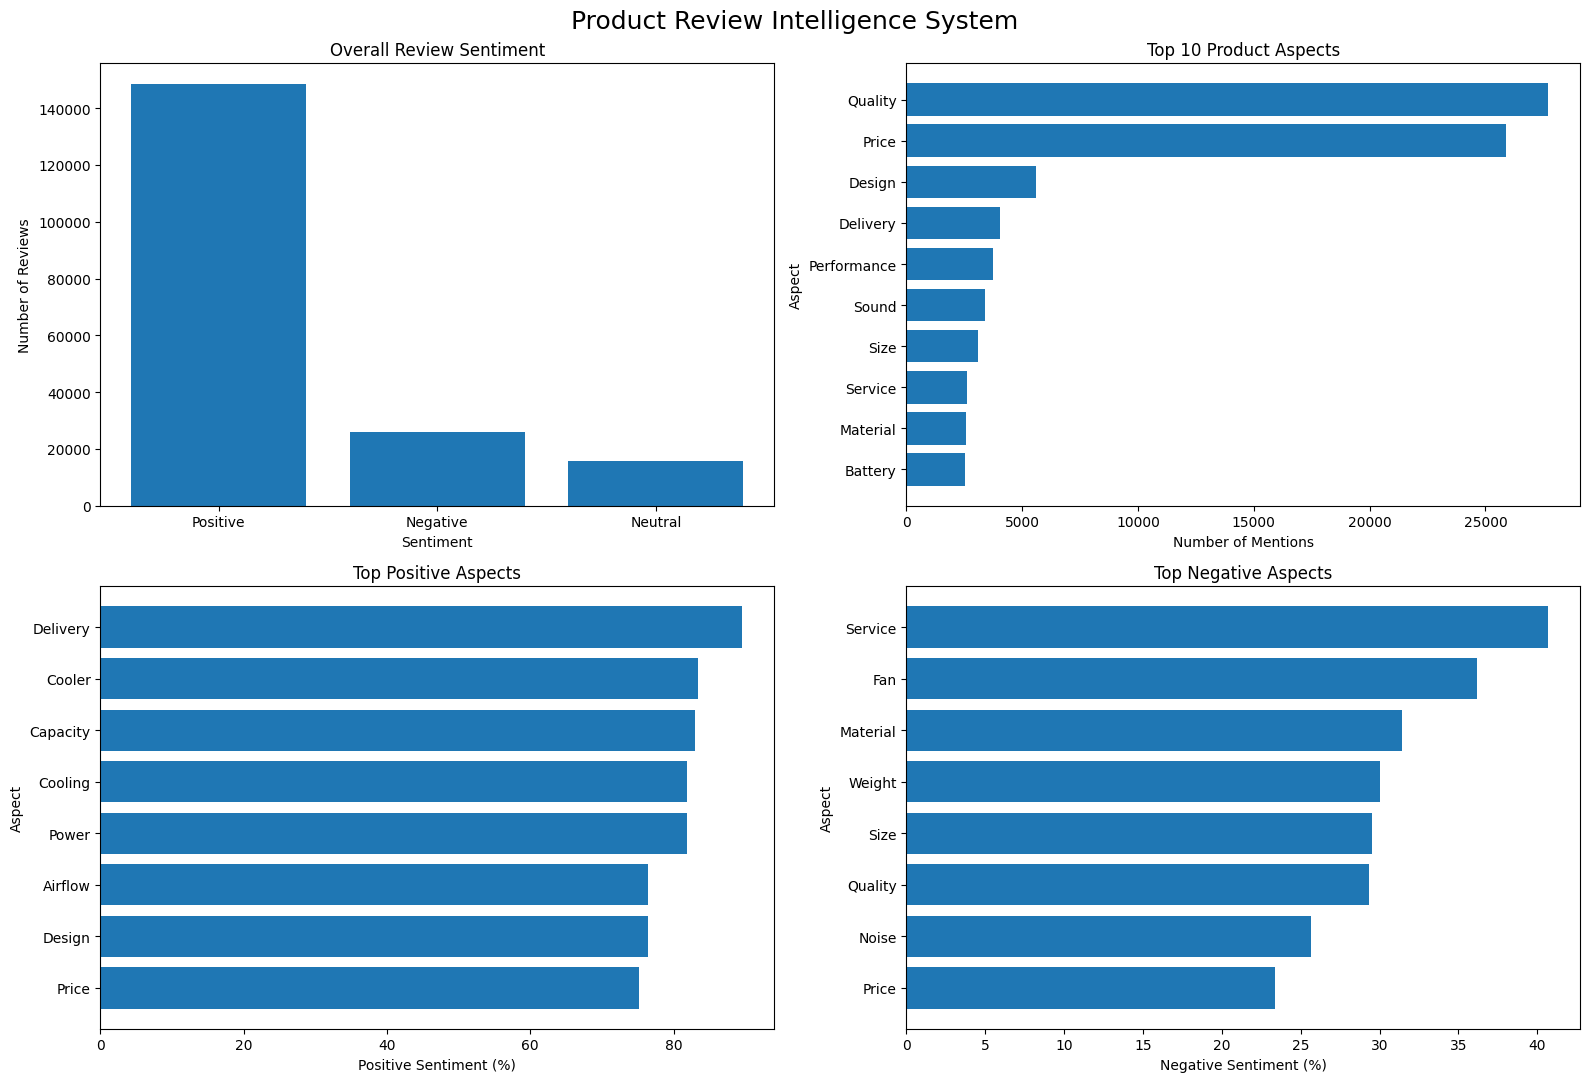

In [131]:
# ============================================
# CELL 47: PROJECT OVERVIEW DASHBOARD
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# --------------------------------------------
# 1. Review Sentiment Distribution
# --------------------------------------------

sentiment_counts = df["sentiment"].value_counts()

axes[0, 0].bar(
    sentiment_counts.index,
    sentiment_counts.values
)

axes[0, 0].set_title("Overall Review Sentiment")
axes[0, 0].set_xlabel("Sentiment")
axes[0, 0].set_ylabel("Number of Reviews")


# --------------------------------------------
# 2. Top 10 Aspects
# --------------------------------------------

top_aspects = aspect_frequency_full.head(10)

axes[0, 1].barh(
    top_aspects["Aspect"][::-1],
    top_aspects["Frequency"][::-1]
)

axes[0, 1].set_title("Top 10 Product Aspects")
axes[0, 1].set_xlabel("Number of Mentions")
axes[0, 1].set_ylabel("Aspect")


# --------------------------------------------
# 3. Top Positive Aspects
# --------------------------------------------

positive_plot = (
    reliable_aspects
    .sort_values("Positive_%", ascending=False)
    .head(8)
    .sort_values("Positive_%")
)

axes[1, 0].barh(
    positive_plot.index,
    positive_plot["Positive_%"]
)

axes[1, 0].set_title("Top Positive Aspects")
axes[1, 0].set_xlabel("Positive Sentiment (%)")
axes[1, 0].set_ylabel("Aspect")


# --------------------------------------------
# 4. Top Negative Aspects
# --------------------------------------------

negative_plot = (
    reliable_aspects
    .sort_values("Negative_%", ascending=False)
    .head(8)
    .sort_values("Negative_%")
)

axes[1, 1].barh(
    negative_plot.index,
    negative_plot["Negative_%"]
)

axes[1, 1].set_title("Top Negative Aspects")
axes[1, 1].set_xlabel("Negative Sentiment (%)")
axes[1, 1].set_ylabel("Aspect")


plt.suptitle(
    "Product Review Intelligence System",
    fontsize=18
)

plt.tight_layout()
plt.show()

In [132]:
# ============================================
# CELL 48: EXPORT PROJECT RESULTS
# ============================================

import os

OUTPUT_DIR = "/kaggle/working/product_review_intelligence"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# --------------------------------------------
# 1. Cleaned Review Dataset
# --------------------------------------------

cleaned_columns = [
    "ProductName_clean",
    "Price_numeric",
    "rating",
    "sentiment",
    "Review_clean",
    "Summary_clean",
    "full_text",
    "word_count",
    "character_count",
    "aspects"
]

df[cleaned_columns].to_csv(
    f"{OUTPUT_DIR}/cleaned_reviews.csv",
    index=False
)


# --------------------------------------------
# 2. Aspect Frequency
# --------------------------------------------

aspect_frequency_full.to_csv(
    f"{OUTPUT_DIR}/aspect_frequency.csv",
    index=False
)


# --------------------------------------------
# 3. Aspect Sentiment Analysis
# --------------------------------------------

aspect_sentiment_export = (
    aspect_sentiment_summary
    .reset_index()
)

aspect_sentiment_export.to_csv(
    f"{OUTPUT_DIR}/aspect_sentiment_analysis.csv",
    index=False
)


# --------------------------------------------
# 4. Product Intelligence
# --------------------------------------------

reliable_products.to_csv(
    f"{OUTPUT_DIR}/product_intelligence.csv",
    index=False
)


print("=" * 60)
print("PROJECT RESULTS EXPORTED SUCCESSFULLY")
print("=" * 60)

print("\nOutput folder:")
print(OUTPUT_DIR)

print("\nFiles created:")

for file in os.listdir(OUTPUT_DIR):
    print("✓", file)

PROJECT RESULTS EXPORTED SUCCESSFULLY

Output folder:
/kaggle/working/product_review_intelligence

Files created:
✓ aspect_sentiment_analysis.csv
✓ product_intelligence.csv
✓ cleaned_reviews.csv
✓ aspect_frequency.csv


In [133]:
# ============================================
# CELL 49: FINAL PROJECT SUMMARY
# ============================================

print("=" * 70)
print("        PRODUCT REVIEW INTELLIGENCE SYSTEM")
print("                 FINAL SUMMARY")
print("=" * 70)

print("""
PROJECT OBJECTIVE
-----------------
The objective of this project is to analyze product reviews using
Aspect-Based Sentiment Analysis (ABSA) and identify customer opinions
about specific product aspects.

KEY FINDINGS
------------
1. The dataset contains 189,869 valid customer reviews.
2. The dataset contains 811 unique products.
3. The average product rating is 4.11/5.
4. 78.13% of reviews are Positive, 8.26% Neutral and 13.61% Negative.
5. 65,352 reviews contain at least one known product aspect.
6. 25 different aspect categories were identified.
7. Quality and Price are the most frequently discussed aspects.
8. Cooling-related aspects such as Cooler, Cooling and Airflow show
   strong positive customer sentiment.
9. Service, Fan, Material, Size and Quality show comparatively higher
   negative sentiment and represent potential improvement areas.
10. The system can analyze new reviews and identify aspect-level
    sentiment with a confidence score.

METHODOLOGY
-----------
Review → Text Cleaning → Aspect Extraction → Aspect Normalization
→ Sentiment Detection → Confidence Scoring → Product Intelligence

LIMITATIONS
-----------
1. The sentiment labels are derived from star ratings and therefore
   represent review-level baseline sentiment rather than manually
   annotated aspect-level ground truth.
2. Aspect extraction uses a manually curated vocabulary and may miss
   previously unseen aspect terms.
3. The ABSA model is rule-based and is intended as a baseline system.
4. Confidence scores are heuristic scores and should not be interpreted
   as calibrated probabilities.
5. Review-level fallback is used when direct aspect sentiment evidence
   is unavailable.
6. The dataset is highly imbalanced toward positive reviews.

FUTURE SCOPE
------------
1. Use transformer-based models such as BERT for advanced ABSA.
2. Use supervised learning with manually annotated aspect-level data.
3. Automatically discover new aspects using topic modeling or embeddings.
4. Improve sentiment handling for negation, sarcasm and contextual language.
5. Build a web dashboard using Streamlit or Flask.
6. Add product comparison and recommendation features.
7. Add real-time review analysis from e-commerce platforms.

CONCLUSION
----------
The developed system demonstrates how customer reviews can be converted
into structured product intelligence. Instead of only determining whether
a review is positive or negative, the system identifies the specific
product aspects responsible for customer satisfaction or dissatisfaction.
This makes the system useful for product analysis, customer feedback
monitoring and business decision-making.
""")

print("=" * 70)
print("PROJECT PIPELINE COMPLETED SUCCESSFULLY!")
print("=" * 70)

        PRODUCT REVIEW INTELLIGENCE SYSTEM
                 FINAL SUMMARY

PROJECT OBJECTIVE
-----------------
The objective of this project is to analyze product reviews using
Aspect-Based Sentiment Analysis (ABSA) and identify customer opinions
about specific product aspects.

KEY FINDINGS
------------
1. The dataset contains 189,869 valid customer reviews.
2. The dataset contains 811 unique products.
3. The average product rating is 4.11/5.
4. 78.13% of reviews are Positive, 8.26% Neutral and 13.61% Negative.
5. 65,352 reviews contain at least one known product aspect.
6. 25 different aspect categories were identified.
7. Quality and Price are the most frequently discussed aspects.
8. Cooling-related aspects such as Cooler, Cooling and Airflow show
   strong positive customer sentiment.
9. Service, Fan, Material, Size and Quality show comparatively higher
   negative sentiment and represent potential improvement areas.
10. The system can analyze new reviews and identify aspect-level